# Laboratoire de test — modèle statistique v4 (projet académique)

Ce notebook contient le **modèle final v4** et un **laboratoire de test en 4 étapes**, pour alimenter le rapport :

| Étape | Question posée | Ce qu'on obtient |
|---|---|---|
| **Modèle v4** | – | Ratings (ClubElo, pi, GAS), 1X2 multinomial, buts Poisson + Dixon-Coles, validation 2021-2026 |
| **Labo 1 : une saison complète** | Un modèle figé au 1er juillet prédit-il bien toute la saison ? | Log loss, RPS, Brier, ECE, % de bons résultats contre 4 références, marchés de buts, par ligue, surprises |
| **Labo 2 : la saison semaine par semaine** | Ré-entraîner chaque lundi améliore-t-il les prédictions ? | Tableau et courbes hebdomadaires : répétition générale du suivi en direct |
| **Labo 3 : suivi en direct** | Le modèle tient-il sur des matchs pas encore joués ? | Journal horodaté des prédictions, noté automatiquement une fois les résultats connus |
| **Labo 4 : export** | – | Classeur Excel avec tous les tableaux, à joindre au rapport |

**Règles du protocole** : aucune information postérieure au coup d'envoi n'entre dans une prédiction. Les cotes sont une *référence externe*, jamais une variable du modèle. La **log loss** est le critère principal : c'est une règle de score propre. On la complète par le RPS (qui tient compte de l'ordre 1 < X < 2), le Brier et la calibration (ECE). Chaque différence est accompagnée d'un **intervalle de confiance à 95 %** obtenu par bootstrap apparié.

*Exécution → Tout exécuter* (≈ 4 min). Pour tester une autre saison, change `SAISON` dans le Labo 1.

In [1]:
!pip -q install statsmodels openpyxl

## Modèle final v4
Calcule les ratings sur toutes les ligues, valide sur 2021-2026, puis estime le modèle final et définit `simulation(dom, ext)`.

In [2]:
# ==================== SIMULATION MATHÉMATIQUE — VERSION 4 (modèle statistique consolidé) ====================
# v4 = v3 + « ratings de buts à score » (modèle GAS, Koopman & Lit 2019) : pour chaque équipe une force d'attaque et une force
#      de défense sur l'échelle log des buts, mises à jour après CHAQUE match par le gradient de la vraisemblance de Poisson :
#          log λ_dom = μ_L + h_L + att_dom − déf_ext        log λ_ext = μ_L − h_L + att_ext − déf_dom
#          att_dom += η (buts_dom − λ_dom) ;  déf_ext −= η (buts_dom − λ_dom)   (et symétriquement pour l'extérieur)
#      η = 0,0125 et rétrécissement ×0,5 lors d'un changement de division, réglés par maximum de vraisemblance sur 2006-2015 SEULEMENT.
# Protocole de sélection (aucune fuite) : réglage 2006-2015 → sélection 2017/18-2020/21 → test final intouché 2021/22-2025/26.
#   Rejeté après test : Elo-buts et pi-ratings « réglés » sur 2015-2020 (gain en sélection qui ne se reproduit pas en test),
#   forces Dixon-Coles dynamiques (redondantes avec GAS et très lentes), ratings GAP, LightGBM (moins bon que la régression).
# Conservé de v3 : ClubElo, pi-ratings, ΔQ (xG approché), ouverture, |ΔElo|, effet ligue, niveau de buts de la ligue, Dixon-Coles ρ,
#   pondération temporelle (demi-vie 4 saisons), marchés dérivés, cotes justes, méthode de Shin, indice de fiabilité.
import numpy as np, pandas as pd, difflib, warnings
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize_scalar
from scipy.stats import poisson
warnings.filterwarnings("ignore")

LIGUES = {"E0": "Premier League", "SP1": "Liga", "I1": "Serie A", "D1": "Bundesliga", "F1": "Ligue 1"}
DEMI_VIE = 4                                                    # saisons
URL = "https://raw.githubusercontent.com/xgabora/Club-Football-Match-Data-2000-2025/main/data/Matches.csv"
raw = pd.read_csv(URL, parse_dates=["MatchDate"], low_memory=False)
raw["Season"] = np.where(raw.MatchDate.dt.month >= 7, raw.MatchDate.dt.year, raw.MatchDate.dt.year - 1)

# ---------- 1. Pi-ratings sur TOUTES les ligues (les promus arrivent avec une note) ----------
R_all = raw.dropna(subset=["HomeTeam", "AwayTeam"]).sort_values("MatchDate", kind="stable").reset_index(drop=True)
PI = {}
def pi_ratings(d, lr=0.035, gamma=0.7, b=10, c=3):
    out = np.zeros((len(d), 4))
    for i, (h, a, gh, ga) in enumerate(zip(d.HomeTeam.values, d.AwayTeam.values, d.FTHome.values, d.FTAway.values)):
        rh = PI.setdefault(h, [0.0, 0.0]); ra = PI.setdefault(a, [0.0, 0.0])          # [note domicile, note extérieur]
        out[i] = rh[0], rh[1], ra[0], ra[1]                                          # valeurs AVANT le match
        if np.isnan(gh): continue
        eh = np.sign(rh[0]) * (b ** (abs(rh[0]) / c) - 1); ea = np.sign(ra[1]) * (b ** (abs(ra[1]) / c) - 1)
        e = (gh - ga) - (eh - ea); s = np.sign(e) * c * np.log10(1 + abs(e))
        o0, o1 = rh[0], ra[1]
        rh[0] += s * lr; rh[1] += (rh[0] - o0) * gamma; ra[1] -= s * lr; ra[0] += (ra[1] - o1) * gamma
    return out
R_all[["pi_hh", "pi_ha", "pi_ah", "pi_aa"]] = pi_ratings(R_all)

# ---------- 1 bis. Ratings de buts à score (GAS) sur toutes les ligues ----------
GAS = {"att": {}, "def": {}, "mu": {}, "ha": {}, "last": {}}
def gas_ratings(d, eta=0.0125, eta_l=0.0001, shrink=0.5):
    att, dfn, mu, ha, last = GAS["att"], GAS["def"], GAS["mu"], GAS["ha"], GAS["last"]
    out = np.full((len(d), 2), np.nan)
    for i, (h, a, L, gh, ga) in enumerate(zip(d.HomeTeam.values, d.AwayTeam.values, d.Division.values, d.FTHome.values, d.FTAway.values)):
        m = mu.setdefault(L, np.log(1.3)); hh = ha.setdefault(L, 0.15)
        for t in (h, a):
            if t in last and last[t] != L: att[t] *= shrink; dfn[t] *= shrink      # promu / relégué
            last[t] = L
        ah, dh, aa, da = att.get(h, 0.), dfn.get(h, 0.), att.get(a, 0.), dfn.get(a, 0.)
        lh, la = m + hh + ah - da, m - hh + aa - dh
        out[i] = lh, la                                                           # valeurs AVANT le match
        if np.isnan(gh) or np.isnan(ga): continue
        eh, ea = gh - np.exp(lh), ga - np.exp(la)
        att[h], dfn[a], att[a], dfn[h] = ah + eta * eh, da - eta * eh, aa + eta * ea, dh - eta * ea
        mu[L], ha[L] = m + eta_l * (eh + ea), hh + eta_l * (eh - ea)
    return out
R_all[["g_lh", "g_la"]] = gas_ratings(R_all)

# ---------- 2. Variables d'avant-match, 5 grands championnats ----------
D = R_all[R_all.Division.isin(LIGUES) & (R_all.Season >= 2005)].dropna(subset=["FTResult"]).reset_index(drop=True)
D["mid"] = np.arange(len(D)); D["y"] = D.FTResult.map({"H": 0, "D": 1, "A": 2})
def side(home):
    s, o = ("Home", "Away") if home else ("Away", "Home")
    return pd.DataFrame({"mid": D.mid, "date": D.MatchDate, "Division": D.Division, "team": D[f"{s}Team"], "home": int(home),
                         "gf": D[f"FT{s}"], "ga": D[f"FT{o}"], "sot_f": D[f"{s}Target"], "sot_a": D[f"{o}Target"], "elo": D[f"{s}Elo"]})
L = pd.concat([side(True), side(False)]).sort_values(["team", "date", "mid"]).reset_index(drop=True)
c_L = L.groupby("Division").gf.sum() / L.groupby("Division").sot_f.sum()
L["xg_f"], L["xg_a"] = L.sot_f * L.Division.map(c_L), L.sot_a * L.Division.map(c_L)
g = L.groupby("team")
mf = g.xg_f.transform(lambda x: x.shift(1).rolling(10, min_periods=5).mean())
ma = g.xg_a.transform(lambda x: x.shift(1).rolling(10, min_periods=5).mean())
L["Q"], L["O"] = mf - ma, mf + ma                                      # qualité de jeu, ouverture
H, A = L[L.home == 1].set_index("mid"), L[L.home == 0].set_index("mid")
X = D.set_index("mid")
X["dElo"] = (X.HomeElo - X.AwayElo) / 100; X["absElo"] = X.dElo.abs()
X["g_lh"], X["g_la"] = D.set_index("mid").g_lh, D.set_index("mid").g_la     # log λ GAS avant match
X["dQ"] = H.Q - A.Q; X["Otot"] = H.O + A.O - 5.5                # centré sur la moyenne (~5,5)
X["pi_diff"] = X.pi_hh - X.pi_aa; X["pi_diff_avg"] = (X.pi_hh + X.pi_ha) / 2 - (X.pi_ah + X.pi_aa) / 2
for lg in ["SP1", "I1", "D1", "F1"]: X[f"lg_{lg}"] = (X.Division == lg).astype(float)   # Premier League = référence
FE_V3 = ["dElo", "absElo", "dQ", "Otot", "pi_diff", "pi_diff_avg", "lg_SP1", "lg_I1", "lg_D1", "lg_F1"]
FE = FE_V3 + ["g_lh", "g_la"]                                          # variables du modèle 1X2 (v4)
Dm = D.sort_values(["Division", "MatchDate", "mid"])
for c, col in (("lg_mh", "FTHome"), ("lg_ma", "FTAway")):
    Dm[c] = Dm.groupby("Division")[col].transform(lambda x: x.shift(1).rolling(380, min_periods=150).mean())
X = X.join(Dm.set_index("mid")[["lg_mh", "lg_ma"]])
X["lg_mh_c"], X["lg_ma_c"] = X.lg_mh - 1.5, X.lg_ma - 1.15            # niveau de buts de la ligue (380 derniers matchs), centré
FE_B = FE + ["lg_mh_c", "lg_ma_c"]
FE_B_V3 = FE_V3 + ["lg_mh_c", "lg_ma_c"]                                     # variables du modèle de buts
X = X.dropna(subset=FE_B)

def poids(TR, s_ref): return 0.5 ** ((s_ref - TR.Season) / DEMI_VIE)
def fit_logit(TR, s_ref, cols=None):
    cols = cols or FE
    return LogisticRegression(C=1e6, max_iter=30000, tol=1e-8).fit(TR[cols], TR.y, sample_weight=poids(TR, s_ref))
def tau(x, y, lh, la, r):
    t = np.ones(np.broadcast(x, y, lh).shape)
    t = np.where((x == 0) & (y == 0), 1 - lh * la * r, t); t = np.where((x == 0) & (y == 1), 1 + lh * r, t)
    t = np.where((x == 1) & (y == 0), 1 + la * r, t);     t = np.where((x == 1) & (y == 1), 1 - r, t)
    return t
def fit_buts(TR, s_ref, cols=None):
    cols = cols or FE_B
    w, Xa = poids(TR, s_ref), sm.add_constant(TR[cols])
    gh = sm.GLM(TR.FTHome, Xa, family=sm.families.Poisson(), freq_weights=w).fit()
    ga = sm.GLM(TR.FTAway, Xa, family=sm.families.Poisson(), freq_weights=w).fit()
    lh, la = gh.predict(Xa).values, ga.predict(Xa).values
    nll = lambda r: -np.sum(w * np.log(np.clip(tau(TR.FTHome.values, TR.FTAway.values, lh, la, r), 1e-12, None)))
    return gh, ga, minimize_scalar(nll, bounds=(-.3, .3), method="bounded").x
def grille(lh, la, rho, gmax=10):
    G = np.arange(gmax + 1)
    M = poisson.pmf(G[:, None], lh) * poisson.pmf(G[None, :], la) * tau(G[:, None], G[None, :], lh, la, rho)
    return M / M.sum()

# ---------- 3. Validation walk-forward (chaque saison prédite avec un modèle entraîné AVANT elle) ----------
def rps(P, y): c = np.cumsum(P - np.eye(3)[y], 1)[:, :2]; return (c ** 2).sum(1) / 2
def ece(P, y):
    e = 0
    for k in range(3):
        b = pd.qcut(P[:, k], 10, labels=False, duplicates="drop"); g = pd.DataFrame({"p": P[:, k], "o": y == k, "b": b}).groupby("b")
        e += (g.p.mean() - g.o.mean()).abs().mul(g.size() / len(y)).sum()
    return e / 3
def bornes(d, k=2000): b = d[np.random.default_rng(0).integers(0, len(d), (k, len(d)))].mean(1); return np.percentile(b, [2.5, 97.5])
te = X[X.Season >= 2021]; P4, P3 = np.zeros((len(te), 3)), np.zeros((len(te), 3)); O4, O3 = np.zeros(len(te)), np.zeros(len(te))
S4, S3 = np.zeros(len(te)), np.zeros(len(te)); P_grid = np.zeros((len(te), 3))
G_ = np.arange(11); TOT = G_[:, None] + G_[None, :]
for s in sorted(te.Season.unique()):
    TR, m = X[X.Season < s], (te.Season == s).values
    P4[m] = fit_logit(TR, s - 1).predict_proba(te.loc[m, FE]); P3[m] = fit_logit(TR, s - 1, FE_V3).predict_proba(te.loc[m, FE_V3])
    for cols, O, SC in ((FE_B, O4, S4), (FE_B_V3, O3, S3)):
        gh, ga, r = fit_buts(TR, s - 1, cols); Xt = sm.add_constant(te.loc[m, cols], has_constant="add")
        lh, la = gh.predict(Xt).values, ga.predict(Xt).values
        x, y_ = te.loc[m, "FTHome"].clip(upper=10).astype(int).values, te.loc[m, "FTAway"].clip(upper=10).astype(int).values
        Ms = np.stack([grille(a_, b_, r) for a_, b_ in zip(lh, la)])
        O[m] = (Ms * (TOT > 2.5)).sum((1, 2)); SC[m] = Ms[np.arange(m.sum()), x, y_]
yt = te.y.values; n = len(yt); ov = (te.FTHome + te.FTAway > 2.5).values
llv = lambda P: -np.log(P[np.arange(n), yt]); llo = lambda p: -np.log(np.where(ov, p, 1 - p))
inv = 1 / te[["OddHome", "OddDraw", "OddAway"]].values; Pm = inv / inv.sum(1, keepdims=True); ok = ~np.isnan(Pm).any(1)
po_m = (1 / te.Over25) / (1 / te.Over25 + 1 / te.Under25); oko = po_m.notna().values
base = np.bincount(yt, minlength=3) / n
print("=" * 88); print(f"VALIDATION WALK-FORWARD — TEST FINAL INTOUCHÉ 2021/22 → 2025/26 ({n} matchs) — plus bas = mieux"); print("=" * 88)
print(f"  {'1X2':28s} {'log loss':>9s} {'RPS':>7s} {'ECE':>6s} {'bon résultat':>13s}")
for nm, P in [("Fréquences (sans modèle)", np.tile(base, (n, 1))), ("Modèle v3", P3), ("Modèle v4", P4)]:
    print(f"  {nm:28s} {llv(P).mean():9.4f} {rps(P, yt).mean():7.4f} {ece(P, yt):6.3f} {np.mean(P.argmax(1) == yt):12.1%}")
print(f"  {'Cotes (référence externe)':28s} {-np.log(Pm[ok][np.arange(ok.sum()), yt[ok]]).mean():9.4f} {rps(Pm[ok], yt[ok]).mean():7.4f} {ece(Pm[ok], yt[ok]):6.3f} {np.mean(Pm[ok].argmax(1) == yt[ok]):12.1%}")
d = llv(P4) - llv(P3); lo_, hi_ = bornes(d)
print(f"  Gain v4 − v3 (1X2) : {1000 * d.mean():+.2f} ×10⁻³  (IC 95 % {1000 * lo_:+.2f} à {1000 * hi_:+.2f})  ·  skill score v4 {1 - llv(P4).mean() / llv(np.tile(base, (n, 1))).mean():.1%}")
print(f"\n  {'Buts':28s} {'LL score exact':>15s} {'LL over 2,5':>12s}")
print(f"  {'Modèle v3':28s} {-np.log(S3).mean():15.4f} {llo(O3).mean():12.4f}")
print(f"  {'Modèle v4':28s} {-np.log(S4).mean():15.4f} {llo(O4).mean():12.4f}")
print(f"  {'Cotes over/under 2,5':28s} {'—':>15s} {llo(po_m.values)[oko].mean():12.4f}   (v4 sur les mêmes matchs : {llo(O4)[oko].mean():.4f})")
d = -np.log(S4) + np.log(S3); lo_, hi_ = bornes(d); d2 = llo(O4) - llo(O3); lo2, hi2 = bornes(d2)
print(f"  Gain v4 − v3 : score exact {1000 * d.mean():+.2f} ×10⁻³ (IC {1000 * lo_:+.2f} à {1000 * hi_:+.2f}) · over 2,5 {1000 * d2.mean():+.2f} ×10⁻³ (IC {1000 * lo2:+.2f} à {1000 * hi2:+.2f})")
tab = pd.DataFrame({"Ligue": te.Division.map(LIGUES), "Saison": te.Season, "v3": llv(P3), "v4": llv(P4), "cotes": np.where(ok, -np.log(np.clip(Pm[np.arange(n), yt], 1e-9, 1)), np.nan)})
print("\n  Log loss 1X2 par ligue :"); print(tab.groupby("Ligue")[["v3", "v4", "cotes"]].mean().round(4).to_string())
print("\n  Log loss 1X2 par saison :"); print(tab.groupby("Saison")[["v3", "v4", "cotes"]].mean().round(4).to_string())
cal = pd.DataFrame({"p": O4, "o": ov}).groupby(pd.qcut(O4, 5), observed=True).mean()
print("\n  Calibration over 2,5 (v4) : " + " · ".join(f"prévu {r.p:.0%} → observé {r.o:.0%}" for r in cal.itertuples()))
P_new = P4

# ---------- 4. Modèle final, estimé sur TOUTES les saisons (poids max sur la plus récente) ----------
S_MAX = int(X.Season.max())
LOGIT = fit_logit(X, S_MAX); GH, GA, RHO = fit_buts(X, S_MAX)
_lam = GH.predict(sm.add_constant(X[FE_B])).values + GA.predict(sm.add_constant(X[FE_B])).values; _m = X.HTHome.notna().values
_htg = (X.HTHome + X.HTAway).values[_m]
K_HT = minimize_scalar(lambda k: -np.sum(_htg * np.log(k * _lam[_m]) - k * _lam[_m]), bounds=(.2, .7), method="bounded").x   # part des buts en 1re MT
# fiabilité : précision observée du modèle (validation) selon sa confiance, et prévisibilité en fin de saison
CONF = pd.DataFrame({"pmax": P_new.max(1), "ok": P_new.argmax(1) == yt})
CONF_BINS = [0, .42, .50, .61, 1]; CONF_ACC = CONF.groupby(pd.cut(CONF.pmax, CONF_BINS), observed=True).ok.mean().values
N_EQ = D.groupby(["Division", "Season"]).HomeTeam.nunique()
cls = list(LOGIT.classes_)                                              # 0 = dom, 1 = nul, 2 = ext
coef = pd.DataFrame({"log[P(1)/P(X)]": np.r_[LOGIT.intercept_[0] - LOGIT.intercept_[1], LOGIT.coef_[0] - LOGIT.coef_[1]],
                     "log[P(2)/P(X)]": np.r_[LOGIT.intercept_[2] - LOGIT.intercept_[1], LOGIT.coef_[2] - LOGIT.coef_[1]]}, index=["constante"] + FE)
coef = coef.join(pd.DataFrame({"log λ_dom": GH.params.values, "log λ_ext": GA.params.values}, index=["constante"] + FE_B), how="outer").loc[["constante"] + FE_B]
print("\n" + "=" * 80); print(f"FORMULES DU MODÈLE FINAL  (estimées sur 2005/06 → {S_MAX}/{S_MAX + 1 - 2000:02d}, demi-vie {DEMI_VIE} saisons ; ρ = {RHO:+.3f})"); print("=" * 80)
print(coef.round(3).to_string(na_rep="—"))
print("Lecture : z1 = somme(coef × variable) de la 1re colonne, z2 de la 2e ; P(X) = 1/(1+e^z1+e^z2), P(1) = e^z1·P(X), P(2) = e^z2·P(X)")
print("Variables : g_lh / g_la = log des buts attendus selon les ratings GAS ; les autres comme en v3.")
print(f"But en 1re mi-temps : λ_MT = {K_HT:.3f} × (λ_dom + λ_ext)  (≈ {K_HT:.0%} des buts avant la pause)")

# ---------- 5. Simulation d'un match ----------
def etat(team):
    t = L[L.team == team].sort_values("date")
    if t.empty: raise ValueError(f"Équipe inconnue : « {team} ». Proches : {difflib.get_close_matches(team, L.team.unique(), 5)}")
    last = t.tail(10)
    lg = t.Division.iloc[-1]; lgm = D[D.Division == lg].tail(380); s_cur = int(D.Season.max())
    joues = int(((D.HomeTeam == team) | (D.AwayTeam == team))[D.Season == s_cur].sum())
    n_eq = N_EQ.get((lg, s_cur), 20)
    return {"elo": t.elo.dropna().iloc[-1], "Q": last.xg_f.mean() - last.xg_a.mean(), "O": last.xg_f.mean() + last.xg_a.mean(),
            "pi": PI.get(team, [0.0, 0.0]), "lg": lg, "att": GAS["att"].get(team, 0.), "def": GAS["def"].get(team, 0.), "last": GAS["last"].get(team, lg), "date": t.date.iloc[-1].date(),
            "lg_mh": lgm.FTHome.mean(), "lg_ma": lgm.FTAway.mean(), "restants": 2 * (n_eq - 1) - joues}

def shin(odds):
    pi = 1 / np.asarray(odds, float); S = pi.sum()
    f = lambda z: (np.sqrt(z * z + 4 * (1 - z) * pi * pi / S) - z).sum() / (2 * (1 - z)) - 1
    z = minimize_scalar(lambda z: f(z) ** 2, bounds=(0, .4), method="bounded").x
    return (np.sqrt(z * z + 4 * (1 - z) * pi * pi / S) - z) / (2 * (1 - z)), S - 1

def simulation(dom, ext, elo_dom=None, elo_ext=None, cotes=None, n_sim=100_000, seed=0, detail=False):
    """cotes = (cote_1, cote_X, cote_2) optionnel : pour comparer le modèle au marché (analyse académique)."""
    a, b = etat(dom), etat(ext)
    ea, eb = elo_dom or a["elo"], elo_ext or b["elo"]
    v = {"dElo": (ea - eb) / 100, "dQ": a["Q"] - b["Q"], "Otot": a["O"] + b["O"] - 5.5,
         "pi_diff": a["pi"][0] - b["pi"][1], "pi_diff_avg": np.mean(a["pi"]) - np.mean(b["pi"])}
    v["absElo"] = abs(v["dElo"])
    L_ = a["lg"]; sh = lambda e, k: e[k] * (0.5 if e["last"] != L_ else 1.0)                  # promu : rétrécissement
    v["g_lh"] = GAS["mu"][L_] + GAS["ha"][L_] + sh(a, "att") - sh(b, "def")
    v["g_la"] = GAS["mu"][L_] - GAS["ha"][L_] + sh(b, "att") - sh(a, "def")
    for lg in ["SP1", "I1", "D1", "F1"]: v[f"lg_{lg}"] = float(a["lg"] == lg)
    v["lg_mh_c"], v["lg_ma_c"] = a["lg_mh"] - 1.5, a["lg_ma"] - 1.15
    xm = pd.DataFrame([v])[FE]; xb = pd.DataFrame([v])[FE_B]
    p = LOGIT.predict_proba(xm)[0]
    cl = coef.loc[["constante"] + FE]; z1 = cl["log[P(1)/P(X)]"].values @ np.r_[1, xm.values[0]]; z2 = cl["log[P(2)/P(X)]"].values @ np.r_[1, xm.values[0]]
    Xc = sm.add_constant(xb, has_constant="add"); lh, la = GH.predict(Xc).iloc[0], GA.predict(Xc).iloc[0]
    M = grille(lh, la, RHO)
    rng = np.random.default_rng(seed); idx = rng.choice(M.size, n_sim, p=M.ravel()); sx, sy = np.divmod(idx, M.shape[1]); tot = sx + sy
    # incertitude : bootstrap du modèle sur 20 rééchantillonnages (detail=False pour aller plus vite)
    if detail:
        boot = []
        for k in range(20):
            Xb = X.sample(len(X), replace=True, random_state=k); boot.append(fit_logit(Xb, S_MAX).predict_proba(xm)[0])
        lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
    print("\n" + "=" * 80); print(f"SIMULATION MATHÉMATIQUE v4 : {dom} – {ext}   ({LIGUES.get(a['lg'], a['lg'])})"); print("=" * 80)
    print(f"Elo {ea:.0f} vs {eb:.0f} (ΔElo {v['dElo']:+.2f})  ·  qualité de jeu {a['Q']:+.2f} vs {b['Q']:+.2f} (ΔQ {v['dQ']:+.2f})")
    print(f"GAS : att/déf {dom} {a['att']:+.2f}/{a['def']:+.2f} · {ext} {b['att']:+.2f}/{b['def']:+.2f} → buts « bruts » {np.exp(v['g_lh']):.2f} – {np.exp(v['g_la']):.2f}")
    print(f"pi-ratings dom {a['pi'][0]:+.2f} / ext {b['pi'][1]:+.2f}  ·  ouverture attendue {v['Otot'] + 5.5:.2f}  ·  données au {max(a['date'], b['date'])}")
    print(f"z1 = {z1:+.3f}   z2 = {z2:+.3f}")
    ic = (lambda k: f"   (IC 95 % {lo[k]:.1%} – {hi[k]:.1%})") if detail else (lambda k: "")
    print(f"\n  ► Victoire {dom:<18s} {p[0]:6.1%}{ic(0)}")
    print(f"  ► Match nul {'':17s} {p[1]:6.1%}{ic(1)}")
    print(f"  ► Victoire {ext:<18s} {p[2]:6.1%}{ic(2)}")
    cs_d, cs_e, btts = M[:, 0].sum(), M[0, :].sum(), M[1:, 1:].sum()
    ht = 1 - np.exp(-K_HT * (lh + la))
    print(f"\n  Buts attendus : {dom} {lh:.2f} · {ext} {la:.2f}   ·   Monte-Carlo ({n_sim:,}) : 1 {np.mean(sx > sy):.1%} · X {np.mean(sx == sy):.1%} · 2 {np.mean(sx < sy):.1%}")
    mk = [("Victoire " + dom, p[0]), ("Match nul", p[1]), ("Victoire " + ext, p[2]),
          ("Plus de 1,5 but", np.mean(tot > 1.5)), ("Plus de 2,5 buts", np.mean(tot > 2.5)), ("Plus de 3,5 buts", np.mean(tot > 3.5)),
          ("Les deux équipes marquent", btts), ("But en 1re mi-temps", ht),
          (f"Cage inviolée {dom}", cs_d), (f"Cage inviolée {ext}", cs_e)]
    print("\n  Marché                              Probabilité   Cote juste (1/p)")
    for nm, q in mk: print(f"  {nm:35s} {q:8.1%}      {1 / q:6.2f}")
    top = sorted(((M[i, j], f"{i}-{j}") for i in range(6) for j in range(6)), reverse=True)[:5]
    print("  Scores les plus probables : " + " · ".join(f"{s} {q:.1%}" for q, s in top))
    k = int(np.digitize(p.max(), CONF_BINS[1:-1]))
    niveau = ["faible", "moyenne", "bonne", "élevée"][k]
    print(f"\n  Fiabilité du pronostic : {niveau} — quand le modèle est aussi confiant, son issue favorite s'est réalisée {CONF_ACC[k]:.0%} du temps (2021–2026)")
    if min(a["restants"], b["restants"]) <= 5:
        print("  ⚠ Fin de saison : ces matchs sont historiquement moins prévisibles (skill score 6,9 % contre 8,9 %).")
    if cotes is not None:
        pm, marge = shin(cotes)
        print(f"\n  Comparaison aux cotes {tuple(cotes)} (marge {marge:.1%}, probabilités de Shin) :")
        for nm, qm, qc in zip(["1", "X", "2"], p, pm): print(f"    {nm} : modèle {qm:.1%} · marché {qc:.1%} · écart {100 * (qm - qc):+.1f} pts")
        print("    Rappel : le marché est en moyenne plus précis que ce modèle (log loss 1X2 0,972 contre 0,982 en test) ; un écart est d'abord un signe d'information manquante.")
    return {"1": p[0], "X": p[1], "2": p[2], "buts_dom": lh, "buts_ext": la, "over25": np.mean(tot > 2.5),
            "btts": btts, "but_1re_MT": ht, "cs_dom": cs_d, "cs_ext": cs_e, "fiabilite": niveau}

simulation("Barcelona", "Real Madrid", detail=True)
simulation("Paris SG", "Marseille", cotes=(1.45, 4.60, 6.50))   # cotes fictives, pour illustrer la comparaison


VALIDATION WALK-FORWARD — TEST FINAL INTOUCHÉ 2021/22 → 2025/26 (8918 matchs) — plus bas = mieux
  1X2                           log loss     RPS    ECE  bon résultat
  Fréquences (sans modèle)        1.0733  0.2299  0.000        43.6%
  Modèle v3                       0.9819  0.1989  0.015        52.8%
  Modèle v4                       0.9813  0.1988  0.011        52.6%
  Cotes (référence externe)       0.9716  0.1956  0.015        53.7%


  Gain v4 − v3 (1X2) : -0.55 ×10⁻³  (IC 95 % -1.86 à +0.65)  ·  skill score v4 8.6%

  Buts                          LL score exact  LL over 2,5
  Modèle v3                             2.9130       0.6807
  Modèle v4                             2.9071       0.6760
  Cotes over/under 2,5                       —       0.6715   (v4 sur les mêmes matchs : 0.6760)


  Gain v4 − v3 : score exact -5.83 ×10⁻³ (IC -8.32 à -3.49) · over 2,5 -4.66 ×10⁻³ (IC -6.52 à -2.97)

  Log loss 1X2 par ligue :
                    v3      v4   cotes
Ligue                                 
Bundesliga      0.9854  0.9851  0.9754
Liga            0.9774  0.9758  0.9666
Ligue 1         0.9964  0.9954  0.9846
Premier League  0.9755  0.9744  0.9609
Serie A         0.9770  0.9782  0.9730

  Log loss 1X2 par saison :
            v3      v4   cotes
Saison                        
2021    0.9887  0.9863  0.9778
2022    0.9835  0.9879  0.9805
2023    0.9681  0.9665  0.9567
2024    0.9806  0.9781  0.9650
2025    0.9907  0.9901  0.9802
2026    0.9328  0.9296  0.9216

  Calibration over 2,5 (v4) : prévu 42% → observé 41% · prévu 48% → observé 48% · prévu 52% → observé 53% · prévu 56% → observé 59% · prévu 65% → observé 66%



FORMULES DU MODÈLE FINAL  (estimées sur 2005/06 → 2026/27, demi-vie 4 saisons ; ρ = -0.055)
             log[P(1)/P(X)]  log[P(2)/P(X)]  log λ_dom  log λ_ext
constante             0.060          -0.052      0.202      0.105
dElo                 -0.014          -0.235      0.053     -0.083
absElo                0.097           0.076     -0.006      0.005
dQ                    0.272          -0.137      0.090     -0.099
Otot                  0.036          -0.022      0.036      0.021
pi_diff               0.067          -0.368     -0.022     -0.184
pi_diff_avg          -0.148           0.363      0.032      0.219
lg_SP1               -0.018          -0.079     -0.016     -0.031
lg_I1                -0.144          -0.045     -0.064     -0.012
lg_D1                -0.128          -0.043      0.004     -0.010
lg_F1                -0.057           0.023     -0.029      0.004
g_lh                  1.075           0.129      0.559      0.092
g_la                 -0.560           0.434      


SIMULATION MATHÉMATIQUE v4 : Barcelona – Real Madrid   (Liga)
Elo 1968 vs 1931 (ΔElo +0.37)  ·  qualité de jeu +0.96 vs +0.92 (ΔQ +0.03)
GAS : att/déf Barcelona +0.91/+0.52 · Real Madrid +0.72/+0.59 → buts « bruts » 2.07 – 1.35
pi-ratings dom +1.74 / ext +1.37  ·  ouverture attendue 5.64  ·  données au 2026-08-31
z1 = +0.692   z2 = -0.034

  ► Victoire Barcelona           50.4%   (IC 95 % 49.0% – 53.0%)
  ► Match nul                    25.2%   (IC 95 % 23.5% – 26.8%)
  ► Victoire Real Madrid         24.4%   (IC 95 % 22.2% – 25.3%)

  Buts attendus : Barcelona 1.88 · Real Madrid 1.27   ·   Monte-Carlo (100,000) : 1 50.8% · X 23.4% · 2 25.8%

  Marché                              Probabilité   Cote juste (1/p)
  Victoire Barcelona                     50.4%        1.98
  Match nul                              25.2%        3.96
  Victoire Real Madrid                   24.4%        4.10
  Plus de 1,5 but                        82.9%        1.21
  Plus de 2,5 buts                       61.0

{'1': np.float64(0.5652997337277413),
 'X': np.float64(0.23264929615160426),
 '2': np.float64(0.2020509701206545),
 'buts_dom': np.float64(2.0384465259082645),
 'buts_ext': np.float64(1.1834423799727978),
 'over25': np.float64(0.62411),
 'btts': np.float64(0.6086732304887059),
 'but_1re_MT': np.float64(0.7557412945863087),
 'cs_dom': np.float64(0.3062228035665836),
 'cs_ext': np.float64(0.1302321526605898),
 'fiabilite': 'bonne'}

## Labo 1 — Test sur une saison complète
Les modèles comparés sont les **fréquences** (aucune information), **Elo seul** (référence naïve), **v3**, **v4** et les **cotes** (référence externe). Tous sont entraînés sur les saisons antérieures uniquement.

*Lecture* : le skill score est le % de log loss gagné par rapport aux fréquences. Un Δ est significatif si son intervalle de confiance ne contient pas 0.

LABO 1 — SAISON 2025/26 (1737 matchs, Premier League, Liga, Serie A, Bundesliga, Ligue 1) — modèles figés au début de saison
           matchs log loss    RPS  Brier   ECE bon résultat skill vs fréquences
modèle                                                                         
Fréquences   1737   1.0723 0.2292 0.6486 0.000        43.9%                0.0%
Elo seul     1737   0.9972 0.2035 0.5952 0.027        51.2%                7.0%
v3           1737   0.9907 0.2014 0.5908 0.029        51.3%                7.6%
v4           1737   0.9901 0.2011 0.5903 0.027        51.4%                7.7%
Cotes        1737   0.9802 0.1980 0.5836 0.029        53.3%                8.6%
  Δ log loss v4 − v3       :  -0.66 ×10⁻³   IC 95 % [-3.19 ; +1.97]  → non significatif
  Δ log loss v4 − Elo seul :  -7.13 ×10⁻³   IC 95 % [-12.69 ; -1.99]  → significatif
  Δ log loss v4 − Cotes    :  +9.85 ×10⁻³   IC 95 % [+3.20 ; +16.51]  → significatif

  Marchés de buts :
                  LL score exact  sc

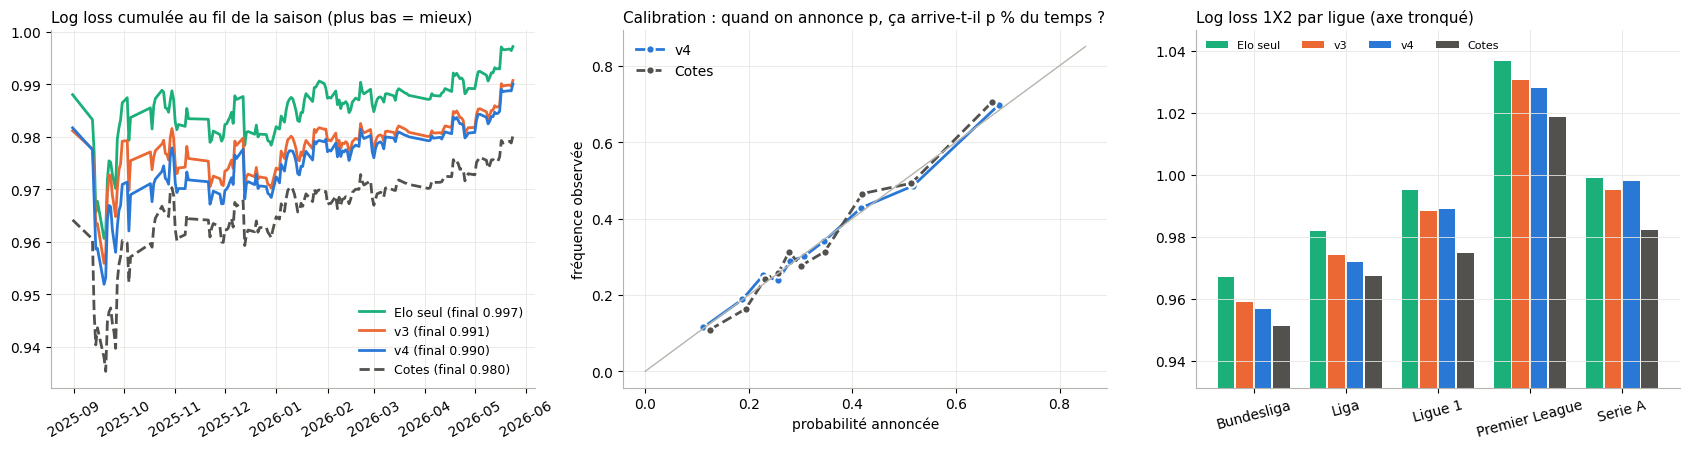


  Les 10 plus grosses surprises pour le modèle (probabilité donnée au résultat réel) :
      Date          Ligue      HomeTeam   AwayTeam Score    P1    PX    P2  p_résultat
2026-01-24     Bundesliga Bayern Munich   Augsburg   1-2 0.883 0.086 0.031       0.031
2026-03-02           Liga   Real Madrid     Getafe   0-1 0.809 0.144 0.046       0.046
2025-12-07           Liga   Real Madrid      Celta   0-2 0.808 0.133 0.059       0.059
2026-05-02     Bundesliga Bayern Munich Heidenheim   3-3 0.903 0.073 0.024       0.073
2025-08-31        Serie A         Inter    Udinese   1-2 0.737 0.184 0.079       0.079
2025-10-25 Premier League       Chelsea Sunderland   1-2 0.751 0.170 0.079       0.079
2026-01-04        Ligue 1     Marseille     Nantes   0-2 0.771 0.149 0.080       0.080
2025-12-14     Bundesliga Bayern Munich      Mainz   2-2 0.883 0.087 0.030       0.087
2025-08-23        Serie A         Milan  Cremonese   1-2 0.708 0.195 0.097       0.097
2026-04-19        Ligue 1      Paris SG   

In [3]:
# ==================== LABO 1 — TEST SUR UNE SAISON COMPLÈTE (à lancer APRÈS la cellule « Simulation mathématique v4 ») ====================
# Protocole : tous les modèles sont entraînés UNIQUEMENT sur les saisons antérieures, puis prédisent toute la saison choisie
# sans jamais voir ses résultats (modèle « figé » au 1er juillet). Les cotes servent de référence externe, jamais d'entrée.
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

SAISON = 2025                                    # 2025 = saison 2025/26 ; essayer aussi 2021, 2022, 2023, 2024
LIGUES_TEST = ["E0", "SP1", "I1", "D1", "F1"]    # ex. ["SP1", "F1"] pour ne tester que Liga + Ligue 1
COUL = {"v4": "#2a78d6", "v3": "#eb6834", "Elo seul": "#1baf7a", "Cotes": "#52514e"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e6e3",
                     "grid.linewidth": .6, "axes.edgecolor": "#b5b4ae", "font.size": 10})

FE_ELO = ["dElo", "absElo"]
S = X[(X.Season == SAISON) & X.Division.isin(LIGUES_TEST)].sort_values("MatchDate").copy()
TR = X[X.Season < SAISON]
assert len(S), "Saison absente des données"
y = S.y.values; n = len(S); ov = (S.FTHome + S.FTAway > 2.5).values; bt = ((S.FTHome > 0) & (S.FTAway > 0)).values
G_ = np.arange(11); TOT = G_[:, None] + G_[None, :]

# ---------- modèles 1X2 ----------
PRED = {}
w = poids(TR, SAISON - 1); f = np.bincount(TR.y, weights=w, minlength=3); PRED["Fréquences"] = np.tile(f / f.sum(), (n, 1))
PRED["Elo seul"] = fit_logit(TR, SAISON - 1, FE_ELO).predict_proba(S[FE_ELO])
PRED["v3"] = fit_logit(TR, SAISON - 1, FE_V3).predict_proba(S[FE_V3])
PRED["v4"] = fit_logit(TR, SAISON - 1).predict_proba(S[FE])
inv = 1 / S[["OddHome", "OddDraw", "OddAway"]].values; okm = ~np.isnan(inv).any(1)
PRED["Cotes"] = np.where(okm[:, None], inv / np.nansum(inv, 1, keepdims=True), np.nan)

# ---------- modèles de buts (grille Dixon-Coles) ----------
BUTS = {}
for nom, cols in (("v3", FE_B_V3), ("v4", FE_B)):
    gh, ga, r = fit_buts(TR, SAISON - 1, cols); Xt = sm.add_constant(S[cols], has_constant="add")
    lh, la = gh.predict(Xt).values, ga.predict(Xt).values
    Ms = np.stack([grille(a_, b_, r) for a_, b_ in zip(lh, la)])
    x_, y_ = S.FTHome.clip(upper=10).astype(int).values, S.FTAway.clip(upper=10).astype(int).values
    top = Ms.reshape(n, -1).argmax(1)
    BUTS[nom] = {"lh": lh, "la": la, "over": (Ms * (TOT > 2.5)).sum((1, 2)), "btts": Ms[:, 1:, 1:].sum((1, 2)),
                 "p_score": Ms[np.arange(n), x_, y_], "score_ok": (top // 11 == x_) & (top % 11 == y_)}
po_m = ((1 / S.Over25) / (1 / S.Over25 + 1 / S.Under25)).values; oko = ~np.isnan(po_m)

# ---------- métriques ----------
def ll(P, yy=y): return -np.log(np.clip(P[np.arange(len(yy)), yy], 1e-12, 1))
def brier(P, yy=y): return ((P - np.eye(3)[yy]) ** 2).sum(1)
def llb(p, o): return -np.log(np.clip(np.where(o, p, 1 - p), 1e-12, 1))
def ic(d, k=2000): b = d[np.random.default_rng(0).integers(0, len(d), (k, len(d)))].mean(1); return np.percentile(b, [2.5, 97.5])

lignes = []
for nom, P in PRED.items():
    m = okm if nom == "Cotes" else np.ones(n, bool)
    lignes.append({"modèle": nom, "matchs": int(m.sum()), "log loss": ll(P[m], y[m]).mean(), "RPS": rps(P[m], y[m]).mean(), "Brier": brier(P[m], y[m]).mean(),
                   "ECE": ece(P[m], y[m]), "bon résultat": np.mean(P[m].argmax(1) == y[m])})
T1 = pd.DataFrame(lignes).set_index("modèle")
T1["skill vs fréquences"] = 1 - T1["log loss"] / T1.loc["Fréquences", "log loss"]
print("=" * 92); print(f"LABO 1 — SAISON {SAISON}/{SAISON + 1 - 2000:02d} ({n} matchs, {', '.join(LIGUES[l] for l in LIGUES_TEST)}) — modèles figés au début de saison"); print("=" * 92)
print(T1.to_string(formatters={"matchs": "{:d}".format, "bon résultat": "{:.1%}".format, "skill vs fréquences": "{:.1%}".format,
                               "log loss": "{:.4f}".format, "RPS": "{:.4f}".format, "Brier": "{:.4f}".format, "ECE": "{:.3f}".format}))
for a, b in (("v4", "v3"), ("v4", "Elo seul"), ("v4", "Cotes")):
    m = okm; d = ll(PRED[a][m], y[m]) - ll(PRED[b][m], y[m]); lo_, hi_ = ic(d)
    verdict = "significatif" if hi_ < 0 or lo_ > 0 else "non significatif"
    print(f"  Δ log loss {a} − {b:9s}: {1000 * d.mean():+6.2f} ×10⁻³   IC 95 % [{1000 * lo_:+.2f} ; {1000 * hi_:+.2f}]  → {verdict}")

T2 = pd.DataFrame({nom: {"LL score exact": -np.log(B["p_score"]).mean(), "score exact trouvé": B["score_ok"].mean(),
                         "LL over 2,5": llb(B["over"], ov).mean(), "Brier over 2,5": ((B["over"] - ov) ** 2).mean(),
                         "LL BTTS": llb(B["btts"], bt).mean(), "buts prévus / match": (B["lh"] + B["la"]).mean()} for nom, B in BUTS.items()}).T
T2.loc["Cotes over/under"] = [np.nan, np.nan, llb(po_m[oko], ov[oko]).mean(), ((po_m[oko] - ov[oko]) ** 2).mean(), np.nan, np.nan]
T2.loc["Réel"] = [np.nan, np.nan, np.nan, np.nan, np.nan, (S.FTHome + S.FTAway).mean()]
print("\n  Marchés de buts :"); print(T2.round(4).to_string(na_rep="—"))

S["Ligue"] = S.Division.map(LIGUES)
T3 = pd.DataFrame({nom: pd.Series(ll(np.nan_to_num(PRED[nom], nan=1 / 3)), index=S.index)[okm].groupby(S.Ligue[okm]).mean() for nom in ["Elo seul", "v3", "v4", "Cotes"]})
T3["écart v4 − cotes"] = T3.v4 - T3.Cotes
print("\n  Log loss 1X2 par ligue :"); print(T3.round(4).to_string())

# ---------- 3 graphiques ----------
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
jours = S.MatchDate.values
for nom in ["Elo seul", "v3", "v4", "Cotes"]:
    l_ = pd.Series(ll(np.nan_to_num(PRED[nom], nan=1 / 3))).groupby(jours).agg(["sum", "size"]).cumsum()
    cum = (l_["sum"] / l_["size"])[l_["size"] >= 100]                     # moyenne cumulée par jour, après 100 matchs
    ax[0].plot(cum.index, cum.values, lw=2, color=COUL[nom], ls="--" if nom == "Cotes" else "-", label=f"{nom} (final {cum.iloc[-1]:.3f})")
ax[0].set_title("Log loss cumulée au fil de la saison (plus bas = mieux)", loc="left", fontsize=11); ax[0].legend(frameon=False, loc="lower right", fontsize=9)
ax[0].tick_params(axis="x", rotation=30)
for nom in ["v4", "Cotes"]:
    P = PRED[nom][okm]; yy = y[okm]; p = P.ravel(); o = (np.eye(3)[yy]).ravel()
    b = pd.qcut(p, 10, labels=False, duplicates="drop"); g = pd.DataFrame({"p": p, "o": o, "b": b}).groupby("b").mean()
    ax[1].plot(g.p, g.o, "-o", lw=2, ms=6, color=COUL[nom], mec="white", mew=1.5, label=nom, ls="--" if nom == "Cotes" else "-")
ax[1].plot([0, .85], [0, .85], color="#b5b4ae", lw=1); ax[1].set_xlabel("probabilité annoncée"); ax[1].set_ylabel("fréquence observée")
ax[1].set_title("Calibration : quand on annonce p, ça arrive-t-il p % du temps ?", loc="left", fontsize=11); ax[1].legend(frameon=False)
lg_ = T3.index; xx = np.arange(len(lg_)); wd = .2
for i, nom in enumerate(["Elo seul", "v3", "v4", "Cotes"]):
    ax[2].bar(xx + (i - 1.5) * wd, T3[nom], wd * .9, color=COUL[nom], label=nom)
ax[2].set_xticks(xx, lg_, rotation=15); ax[2].set_ylim(T3[["Elo seul", "v3", "v4", "Cotes"]].values.min() - .02, T3[["Elo seul", "v3", "v4", "Cotes"]].values.max() + .01)
ax[2].set_title("Log loss 1X2 par ligue (axe tronqué)", loc="left", fontsize=11); ax[2].legend(frameon=False, ncol=4, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

# ---------- surprises et export ----------
S["P1"], S["PX"], S["P2"] = PRED["v4"].T
S["p_résultat"] = PRED["v4"][np.arange(n), y]
S["λ_dom"], S["λ_ext"], S["P_over25"], S["P_btts"] = BUTS["v4"]["lh"], BUTS["v4"]["la"], BUTS["v4"]["over"], BUTS["v4"]["btts"]
S["LL_v4"], S["LL_cotes"] = ll(PRED["v4"]), np.where(okm, ll(np.nan_to_num(PRED["Cotes"], nan=1 / 3)), np.nan)
print("\n  Les 10 plus grosses surprises pour le modèle (probabilité donnée au résultat réel) :")
sur = S.nsmallest(10, "p_résultat")
print(sur.assign(Date=sur.MatchDate.dt.date, Score=sur.FTHome.astype(int).astype(str) + "-" + sur.FTAway.astype(int).astype(str))
      [["Date", "Ligue", "HomeTeam", "AwayTeam", "Score", "P1", "PX", "P2", "p_résultat"]].round(3).to_string(index=False))
LABO1 = {"1X2": T1, "buts": T2, "ligues": T3}
S[["MatchDate", "Ligue", "HomeTeam", "AwayTeam", "FTHome", "FTAway", "FTResult", "P1", "PX", "P2", "λ_dom", "λ_ext", "P_over25", "P_btts", "LL_v4", "LL_cotes"]] \
    .to_csv(f"labo1_predictions_{SAISON}.csv", index=False)
print(f"\n  → prédictions match par match enregistrées dans labo1_predictions_{SAISON}.csv")


## Labo 2 — Rejouer la saison semaine par semaine
C'est la simulation exacte de ce que sera le suivi hebdomadaire. On découpe la saison en semaines (lundi → dimanche). Chaque lundi, le modèle est ré-entraîné sur tout ce qui est connu, puis il prédit la semaine.

37 semaines rejouées en 74 s
LABO 2 — SAISON 2025/26 REJOUÉE SEMAINE PAR SEMAINE
  Log loss 1X2 : v4 ré-entraîné chaque semaine 0.9905 · v4 figé 0.9901 · cotes 0.9802
  Gain du ré-entraînement hebdomadaire : +0.43 ×10⁻³  IC 95 % [-0.19 ; +1.03]
  Écart v4 hebdo − cotes : +10.28 ×10⁻³  IC 95 % [+3.63 ; +16.90]
  Bons résultats : v4 51.5% · cotes 53.3%  ·  over 2,5 : v4 0.6806 · cotes 0.6773
  Semaines où v4 fait mieux que les cotes : 43% (16/37)

  Tableau hebdomadaire (extrait : 10 premières et 5 dernières semaines) :
            matchs LL_v4_hebdo LL_v4_figé LL_cotes bons_v4 bons_cotes LL_over_v4 LL_over_cotes cumul_v4_hebdo cumul_v4_figé cumul_cotes
semaine du                                                                                                                             
2025-08-11      24       0.968      0.968    0.970     50%        50%      0.714         0.708          0.968         0.968       0.970
2025-08-18      43       0.994      0.994    0.964     51%        53

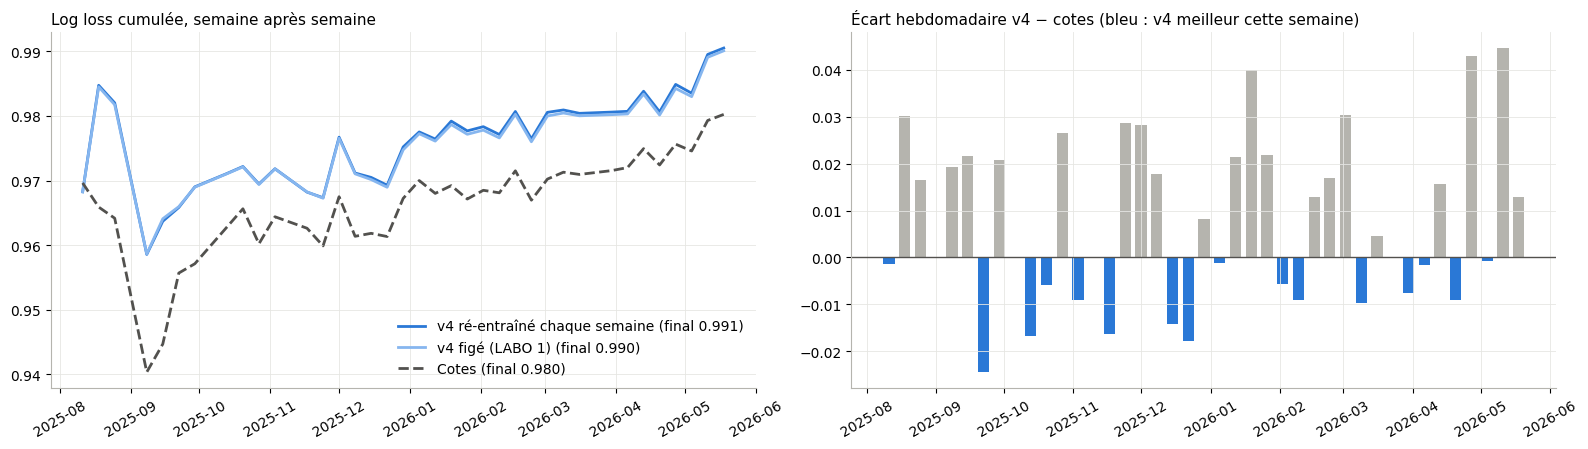


  → tableau hebdomadaire complet enregistré dans labo2_semaines_2025.csv


In [4]:
# ==================== LABO 2 — REJOUER LA SAISON SEMAINE PAR SEMAINE (après LABO 1) ====================
# Répétition générale du suivi hebdomadaire : chaque lundi, le modèle v4 est RÉ-ENTRAÎNÉ avec tous les matchs joués avant
# ce lundi (y compris ceux de la saison en cours), puis il prédit les matchs de la semaine. On compare au modèle figé
# du LABO 1 et aux cotes. Aucune donnée future n'est utilisée : les variables (Elo, pi, GAS, forme) sont calculées avant chaque match.
import time
t0 = time.time()
S["semaine"] = S.MatchDate.dt.to_period("W-SUN").dt.start_time            # lundi de la semaine du match
P_heb = np.zeros((n, 3)); O_heb = np.zeros(n); SC_heb = np.zeros(n)
for k, (lundi, idx) in enumerate(S.groupby("semaine").groups.items()):
    m = S.index.isin(idx)
    TRw = X[X.MatchDate < lundi]                                            # tout ce qui est connu avant ce lundi
    P_heb[m] = fit_logit(TRw, SAISON).predict_proba(S.loc[m, FE])          # poids : saison en cours = 1, N-4 = 0,5
    gh, ga, r = fit_buts(TRw, SAISON); Xt = sm.add_constant(S.loc[m, FE_B], has_constant="add")
    lh, la = gh.predict(Xt).values, ga.predict(Xt).values
    Ms = np.stack([grille(a_, b_, r) for a_, b_ in zip(lh, la)])
    O_heb[m] = (Ms * (TOT > 2.5)).sum((1, 2))
    SC_heb[m] = Ms[np.arange(m.sum()), S.loc[m, "FTHome"].clip(upper=10).astype(int).values, S.loc[m, "FTAway"].clip(upper=10).astype(int).values]
print(f"{S.semaine.nunique()} semaines rejouées en {time.time() - t0:.0f} s")

S["LL_heb"] = ll(P_heb); S["ok_heb"] = P_heb.argmax(1) == y; S["ok_cotes"] = np.nan_to_num(PRED["Cotes"]).argmax(1) == y
S["LL_over_heb"] = llb(O_heb, ov); S["LL_over_cotes"] = np.where(oko, llb(np.nan_to_num(po_m, nan=.5), ov), np.nan)
W = S.groupby("semaine").agg(matchs=("y", "size"), LL_v4_hebdo=("LL_heb", "mean"), LL_v4_figé=("LL_v4", "mean"), LL_cotes=("LL_cotes", "mean"),
                             bons_v4=("ok_heb", "mean"), bons_cotes=("ok_cotes", "mean"), LL_over_v4=("LL_over_heb", "mean"), LL_over_cotes=("LL_over_cotes", "mean"))
cum = lambda c: (S.groupby("semaine")[c].sum().cumsum() / S.groupby("semaine").size().cumsum())
W["cumul_v4_hebdo"], W["cumul_v4_figé"], W["cumul_cotes"] = cum("LL_heb"), cum("LL_v4"), cum("LL_cotes")
W.index = W.index.date; W.index.name = "semaine du"

print("=" * 92); print(f"LABO 2 — SAISON {SAISON}/{SAISON + 1 - 2000:02d} REJOUÉE SEMAINE PAR SEMAINE"); print("=" * 92)
d = S.LL_heb.values - S.LL_v4.values; lo_, hi_ = ic(d)
d2 = (S.LL_heb - S.LL_cotes).values[okm]; lo2, hi2 = ic(d2)
print(f"  Log loss 1X2 : v4 ré-entraîné chaque semaine {S.LL_heb.mean():.4f} · v4 figé {S.LL_v4.mean():.4f} · cotes {np.nanmean(S.LL_cotes):.4f}")
print(f"  Gain du ré-entraînement hebdomadaire : {1000 * d.mean():+.2f} ×10⁻³  IC 95 % [{1000 * lo_:+.2f} ; {1000 * hi_:+.2f}]")
print(f"  Écart v4 hebdo − cotes : {1000 * d2.mean():+.2f} ×10⁻³  IC 95 % [{1000 * lo2:+.2f} ; {1000 * hi2:+.2f}]")
print(f"  Bons résultats : v4 {S.ok_heb.mean():.1%} · cotes {S.ok_cotes[okm].mean():.1%}  ·  over 2,5 : v4 {S.LL_over_heb.mean():.4f} · cotes {np.nanmean(S.LL_over_cotes):.4f}")
print(f"  Semaines où v4 fait mieux que les cotes : {np.mean(W.LL_v4_hebdo < W.LL_cotes):.0%} ({int((W.LL_v4_hebdo < W.LL_cotes).sum())}/{len(W)})")
print("\n  Tableau hebdomadaire (extrait : 10 premières et 5 dernières semaines) :")
fmt = {c: "{:.3f}".format for c in W.columns if c.startswith(("LL", "cumul"))} | {"bons_v4": "{:.0%}".format, "bons_cotes": "{:.0%}".format}
print(pd.concat([W.head(10), W.tail(5)]).to_string(formatters=fmt))

fig, ax = plt.subplots(1, 2, figsize=(16, 4.6))
xw = pd.to_datetime(W.index)
for c, nom, col, ls in (("cumul_v4_hebdo", "v4 ré-entraîné chaque semaine", COUL["v4"], "-"), ("cumul_v4_figé", "v4 figé (LABO 1)", "#86b6ef", "-"),
                        ("cumul_cotes", "Cotes", COUL["Cotes"], "--")):
    ax[0].plot(xw, W[c], lw=2, color=col, ls=ls, label=f"{nom} (final {W[c].iloc[-1]:.3f})")
ax[0].set_title("Log loss cumulée, semaine après semaine", loc="left", fontsize=11); ax[0].legend(frameon=False); ax[0].tick_params(axis="x", rotation=30)
diff = (W.LL_v4_hebdo - W.LL_cotes).values
ax[1].bar(xw, diff, width=5, color=np.where(diff < 0, COUL["v4"], "#b5b4ae"))
ax[1].axhline(0, color="#52514e", lw=1)
ax[1].set_title("Écart hebdomadaire v4 − cotes (bleu : v4 meilleur cette semaine)", loc="left", fontsize=11); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
LABO2 = W
W.to_csv(f"labo2_semaines_{SAISON}.csv"); print(f"\n  → tableau hebdomadaire complet enregistré dans labo2_semaines_{SAISON}.csv")


## Labo 3 — Suivi en direct, chaque semaine
1. **Avant la journée** : *Tout exécuter* (données à jour), puis `predire_journee([...])` avec les affiches. Les noms d'équipes doivent être ceux du dataset ; en cas d'erreur, des noms proches sont proposés.
2. **Après la journée** : `evaluer_journal()`. Le dataset xgabora est mis à jour régulièrement, mais avec quelques jours de décalage.

Le journal est enregistré sur Google Drive (`MyDrive/labo_foot/`). Les prédictions sont horodatées **avant** les matchs : c'est la preuve qu'elles n'ont pas été ajustées après coup.

In [5]:
# ==================== LABO 3 — SUIVI EN DIRECT, CHAQUE SEMAINE (après la cellule v4) ====================
# Routine hebdomadaire :
#   1) AVANT la journée : relancer la cellule v4 (données à jour), puis predire_journee([...]) → les prédictions sont
#      horodatées et ajoutées au journal (fichier CSV). Elles ne doivent plus jamais être modifiées.
#   2) APRÈS la journée (quand le dataset contient les résultats) : evaluer_journal() → score du modèle sur les matchs joués.
# Conseil : monter Google Drive pour garder le journal d'une session Colab à l'autre.
import os, io, contextlib, datetime as dt
try:
    from google.colab import drive; drive.mount("/content/drive"); DOSSIER = "/content/drive/MyDrive/labo_foot"
except Exception:
    DOSSIER = "labo_foot"                                                   # hors Colab : dossier local
os.makedirs(DOSSIER, exist_ok=True); JOURNAL = f"{DOSSIER}/journal_predictions.csv"
DATA_AU = raw.MatchDate.max().date()

def predire_journee(matchs, version="v4"):
    """matchs = [("Équipe dom", "Équipe ext", "AAAA-MM-JJ"), ...]  (noms comme dans le dataset ; la date du match est facultative)"""
    lignes = []
    for m in matchs:
        dom, ext = m[0], m[1]; date = m[2] if len(m) > 2 else ""
        try:
            with contextlib.redirect_stdout(io.StringIO()): r = simulation(dom, ext)
        except ValueError as e:
            print("  ✗", e); continue
        lignes.append({"horodatage": dt.datetime.now().strftime("%Y-%m-%d %H:%M"), "données_au": str(DATA_AU), "version": version,
                       "date_match": date, "dom": dom, "ext": ext, "P1": round(r["1"], 4), "PX": round(r["X"], 4), "P2": round(r["2"], 4),
                       "buts_dom": round(r["buts_dom"], 3), "buts_ext": round(r["buts_ext"], 3), "P_over25": round(r["over25"], 4),
                       "P_btts": round(r["btts"], 4), "fiabilité": r["fiabilite"],
                       "pronostic": ["1", "X", "2"][int(np.argmax([r["1"], r["X"], r["2"]]))]})
    new = pd.DataFrame(lignes)
    if new.empty: return new
    old = pd.read_csv(JOURNAL) if os.path.exists(JOURNAL) else pd.DataFrame()
    pd.concat([old, new], ignore_index=True).to_csv(JOURNAL, index=False)
    jours = (dt.date.today() - DATA_AU).days
    print(f"{len(new)} prédictions ajoutées au journal ({JOURNAL}) — données au {DATA_AU}" + (f"  ⚠ données vieilles de {jours} jours : les derniers résultats ne sont peut-être pas encore intégrés" if jours > 7 else ""))
    show = new[["date_match", "dom", "ext", "P1", "PX", "P2", "buts_dom", "buts_ext", "P_over25", "P_btts", "pronostic", "fiabilité"]].copy()
    for c in ["P1", "PX", "P2", "P_over25", "P_btts"]: show[c] = show[c].map("{:.0%}".format)
    print(show.to_string(index=False)); return new

def evaluer_journal():
    """Relit le dataset (résultats à jour) et note chaque prédiction du journal dont le match a été joué APRÈS la prédiction."""
    if not os.path.exists(JOURNAL): print("Journal vide : lancer d'abord predire_journee(...)"); return None
    J = pd.read_csv(JOURNAL, parse_dates=["horodatage"])
    res = pd.read_csv(URL, usecols=["MatchDate", "HomeTeam", "AwayTeam", "FTHome", "FTAway", "FTResult", "OddHome", "OddDraw", "OddAway", "Over25", "Under25"],
                      parse_dates=["MatchDate"], low_memory=False).dropna(subset=["FTResult"])
    out = []
    for i, j in J.iterrows():
        c = res[(res.HomeTeam == j.dom) & (res.AwayTeam == j.ext) & (res.MatchDate >= j.horodatage.normalize())]
        if isinstance(j.date_match, str) and j.date_match:
            c = c[(c.MatchDate - pd.Timestamp(j.date_match)).abs() <= pd.Timedelta(days=3)]
        if len(c): out.append((i, c.sort_values("MatchDate").iloc[0]))
    if not out: print(f"Aucun match du journal n'est encore joué dans le dataset ({len(J)} prédictions en attente)."); return None
    E = J.loc[[i for i, _ in out]].copy(); R_ = pd.DataFrame([r for _, r in out], index=E.index)
    E = E.join(R_[["MatchDate", "FTHome", "FTAway", "FTResult", "OddHome", "OddDraw", "OddAway", "Over25", "Under25"]])
    yy = E.FTResult.map({"H": 0, "D": 1, "A": 2}).values; P = E[["P1", "PX", "P2"]].values
    iv = 1 / E[["OddHome", "OddDraw", "OddAway"]].values; Pm = iv / iv.sum(1, keepdims=True); ok = ~np.isnan(Pm).any(1)
    o = (E.FTHome + E.FTAway > 2.5).values
    E["LL_modèle"] = ll(P, yy); E["LL_cotes"] = np.where(ok, ll(np.nan_to_num(Pm, nan=1 / 3), yy), np.nan); E["pronostic_juste"] = P.argmax(1) == yy
    E["LL_over"] = llb(E.P_over25.values, o)
    print("=" * 92); print(f"ÉVALUATION DU JOURNAL : {len(E)} matchs joués sur {len(J)} prédictions"); print("=" * 92)
    print(f"  Log loss 1X2 : modèle {E.LL_modèle.mean():.4f} · cotes {E.LL_cotes.mean():.4f} (mêmes matchs) · sans modèle ≈ 1,07")
    print(f"  RPS : modèle {rps(P, yy).mean():.4f} · cotes {rps(Pm[ok], yy[ok]).mean():.4f}")
    print(f"  Pronostics justes : {E.pronostic_juste.mean():.1%}   ·   log loss over 2,5 : {E.LL_over.mean():.4f}")
    if len(E) >= 30:
        lo_, hi_ = ic(E.LL_modèle.values[ok] - E.LL_cotes.values[ok])
        print(f"  Écart modèle − cotes : IC 95 % [{1000 * lo_:+.1f} ; {1000 * hi_:+.1f}] ×10⁻³")
    else:
        print(f"  (moins de 30 matchs : les écarts ne sont pas encore interprétables statistiquement)")
    E["semaine"] = E.MatchDate.dt.to_period("W-SUN").dt.start_time.dt.date
    Wk = E.groupby("semaine").agg(matchs=("P1", "size"), LL_modèle=("LL_modèle", "mean"), LL_cotes=("LL_cotes", "mean"), justes=("pronostic_juste", "mean"))
    Wk["cumul_modèle"] = (E.groupby("semaine").LL_modèle.sum().cumsum() / E.groupby("semaine").size().cumsum()).values
    print("\n  Par semaine :"); print(Wk.round(3).to_string())
    E["score"] = E.FTHome.astype(int).astype(str) + "-" + E.FTAway.astype(int).astype(str)
    print("\n  Détail :"); print(E[["MatchDate", "dom", "ext", "score", "P1", "PX", "P2", "pronostic", "pronostic_juste", "LL_modèle", "LL_cotes"]]
                             .assign(MatchDate=E.MatchDate.dt.date).round(3).to_string(index=False))
    E.to_csv(f"{DOSSIER}/journal_evalue.csv", index=False); print(f"\n  → {DOSSIER}/journal_evalue.csv")
    return E

# ---------- Exemple : remplacer par les affiches de la prochaine journée (noms exacts du dataset) ----------
predire_journee([("Arsenal", "Chelsea"), ("Barcelona", "Sevilla"), ("Paris SG", "Lyon"), ("Inter", "Milan"), ("Bayern Munich", "Dortmund")])
evaluer_journal()


5 prédictions ajoutées au journal (labo_foot/journal_predictions.csv) — données au 2026-09-03  ⚠ données vieilles de 25 jours : les derniers résultats ne sont peut-être pas encore intégrés
date_match           dom      ext  P1  PX  P2  buts_dom  buts_ext P_over25 P_btts pronostic fiabilité
                 Arsenal  Chelsea 68% 20% 12%     2.028     0.849      55%    50%         1    élevée
               Barcelona  Sevilla 81% 13%  6%     2.881     0.784      71%    52%         1    élevée
                Paris SG     Lyon 62% 21% 17%     2.134     1.077      62%    59%         1    élevée
                   Inter    Milan 62% 23% 15%     1.932     0.915      54%    52%         1    élevée
           Bayern Munich Dortmund 65% 19% 15%     2.606     1.258      74%    67%         1    élevée


Aucun match du journal n'est encore joué dans le dataset (10 prédictions en attente).


## Labo 4 — Export pour le rapport

In [6]:
# ==================== LABO 4 — EXPORT DES RÉSULTATS POUR LE RAPPORT ====================
# Rassemble les tableaux des labos 1 et 2 (et le journal évalué s'il existe) dans un classeur Excel à joindre au rapport.
fichier = f"{DOSSIER}/rapport_labo_{SAISON}.xlsx"
with pd.ExcelWriter(fichier) as xw:
    LABO1["1X2"].to_excel(xw, sheet_name="1X2 saison"); LABO1["buts"].to_excel(xw, sheet_name="Marchés de buts")
    LABO1["ligues"].to_excel(xw, sheet_name="Par ligue"); LABO2.to_excel(xw, sheet_name="Semaine par semaine")
    S[["MatchDate", "Ligue", "HomeTeam", "AwayTeam", "FTHome", "FTAway", "P1", "PX", "P2", "LL_v4", "LL_heb", "LL_cotes"]].to_excel(xw, sheet_name="Matchs", index=False)
    if os.path.exists(f"{DOSSIER}/journal_evalue.csv"): pd.read_csv(f"{DOSSIER}/journal_evalue.csv").to_excel(xw, sheet_name="Suivi en direct", index=False)
print("Classeur du rapport :", fichier)
try:
    from google.colab import files; files.download(fichier)
except Exception: pass


Classeur du rapport : labo_foot/rapport_labo_2025.xlsx
